In [1]:

import torch.nn as nn
import numpy as np

import warnings
import numpy as np

warnings.filterwarnings("ignore")
import h5py
import numpy as np


In [2]:
dict = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

In [3]:
import pandas as pd

oids_df = pd.read_parquet('/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/partitions/240627/partitions.parquet')['oid'].unique().tolist()

In [4]:
oids_df[:10]


['ZTF18adldhip',
 'ZTF19aasbgeb',
 'ZTF18aayfbqd',
 'ZTF19ablyzbl',
 'ZTF18actabfv',
 'ZTF18aaztkvq',
 'ZTF21aaphzsw',
 'ZTF19aarhrcv',
 'ZTF17aaajmxw',
 'ZTF18acrvact']

In [5]:
from alerce.core import Alerce
from tqdm import tqdm
import h5py
class MineStamps:

    def __init__(self,oids_list:list,n_stamps, output_filename,save_template = False,save_diff = False,save_science= False):
        self.n_stamps = n_stamps
        self.oids_list = oids_list
        self.output_filename = output_filename
        self._initialize_dataset()
        self.client = Alerce()
        for idx,oid in enumerate(oids_list):
            science,template,diff = self.mine_for_oid(oid)
            print(science.shape,template.shape,diff.shape)
            with h5py.File(f'./{self.output_filename}', 'r+') as f:
                f.get('science_stamps')[idx,:, :, :] = science
                f.get('template_stamps')[idx,:, :, :] = template
                f.get('diff_stamps')[idx,:, :, :] = diff
                
                
                print(f.get('science_stamps'))

    def _initialize_dataset(self):
        dataset_len = len(self.oids_list)
        with h5py.File(f'./{self.output_filename}', 'w') as f:
            f.create_dataset('science_stamps', data=np.zeros([dataset_len,63,63,self.n_stamps]))
            f.create_dataset('template_stamps', data=np.zeros([dataset_len,63,63,self.n_stamps]))
            f.create_dataset('diff_stamps', data=np.zeros([dataset_len,63,63,self.n_stamps]))
          
    
    def mine_for_oid(self,oid):       
        
        science,template,diff =None,None,None
        dets = self.client.query_detections('{}'.format(oid))
        candids = set()
        
        for det in dets:
            candids.add(det['candid'])
        
        candids = list(candids)
        collect_stamps = []
        collect_candids = []
        
        for idx,candid in enumerate(candids[:self.n_stamps]):
            #try:
                #print(str(candid))
                stamps = self.client.get_stamps("{}".format(oid), candid = candid)
                #stamps = [np.expand_dims(stamp,axis = -1) for stamp in stamps]
                print(candid,stamps)
                science = (
                np.concatenate([science,np.expand_dims( stamps[0].data,axis = -1)],axis = -1)
                if science is not None
                else np.expand_dims(stamps[0].data,axis = -1))
                template = (
                np.concatenate([template,np.expand_dims( stamps[1].data,axis = -1)],axis = -1)
                if template is not None
                else np.expand_dims(stamps[1].data,axis = -1))
                diff = (
                np.concatenate([diff,np.expand_dims( stamps[-1].data,axis = -1)],axis = -1)
                if diff is not None
                else np.expand_dims(stamps[-1].data,axis = -1))
                collect_candids.append(str(candid)) 
        return science,template,diff
test = MineStamps(oids_df[:10],5, 'stamps.h5')

AttributeError: 'Alerce' object has no attribute 'get_stamps'

(10, 63, 63, 5)
(3969,)


<Axes: ylabel='Count'>

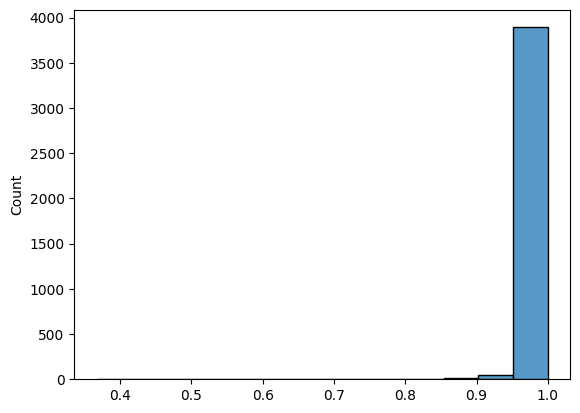

In [36]:
from alerce.core import Alerce
from tqdm import tqdm
import h5py
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
with h5py.File(f'./stamps.h5', 'r') as f:
    science = f.get('science_stamps')[:]

science = (science/science.max(axis = -1,keepdims=True)) 
print(science.shape)
img = science[0,:,:,0].reshape(-1)
print(img.shape)
sns.histplot(img)

In [26]:
from alerce.core import Alerce
from tqdm import tqdm
import pandas as pd
import seaborn as sns
client = Alerce()
import matplotlib.pyplot as plt

#stamps = client.plot_stamps("ZTF18aavoomb")
dets = client.query_detections('ZTF18aavoomb')




In [2]:
df = pd.DataFrame()
for det in dets:
    new_df = pd.Series(det).to_frame().T
    #display(new_df.T)
    df = pd.concat([new_df,df])
display(df)
display(df[df['has_stamp']])

,tid,mjd,candid,fid,pid,diffmaglim,isdiffpos,nid,distnr,magpsf,...,drb,magapbig,sigmagapbig,rfid,has_stamp,corrected,dubious,step_id_corr,phase,parent_candid
0,ztf,60788.39875,3034398753715010021,2,3034398753715,20.488104,-1,3034,0.177137,18.736038,...,1.0,18.7309,0.0988,481120237,True,True,False,27.5.6,0.0,NaN
0,ztf,60786.399491,3032399493715010012,2,3032399493715,19.783247,-1,3032,0.244108,18.878714,...,0.999991,18.9413,0.229,481120237,True,True,False,27.5.6,0.0,NaN
0,ztf,60780.407836,3026407833715015014,2,3026407833715,19.522005,1,3026,0.225096,17.36037,...,1.0,17.4148,0.0749,481120237,True,True,False,27.5.6,0.0,NaN
0,ztf,60775.461759,3021461753715010008,1,3021461753715,19.67957,-1,3021,0.21417,18.285685,...,1.0,18.1091,0.1139,481120137,True,True,False,27.5.4,0.0,NaN
0,ztf,60775.437593,3021437593715010009,2,3021437593715,19.862942,-1,3021,0.144481,18.601664,...,0.999855,18.3776,0.1345,481120237,True,True,False,27.5.4,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,ztf,58281.20978,527209783715015013,2,527209783715,20.645897,1,527,0.194999,17.33435,...,0.0,17.3756,0.0297,481120237,False,True,False,bulk_1.0.0,0.0,543291493715010001
0,ztf,58278.271412,524271413715010002,2,524271413715,20.413221,-1,524,0.096787,18.506853,...,0.0,18.4177,0.0774,481120237,False,True,False,bulk_1.0.0,0.0,543291493715010001
0,ztf,58268.374363,514374363715015003,2,514374363715,19.2492,1,514,0.208634,17.6911,...,NaN,17.7323,0.1288,NaN,False,True,False,bulk_1.0.0,0.0,543291493715010001
0,ztf,58257.356782,503356783715015005,2,503356783715,20.4907,1,503,0.495298,18.6036,...,NaN,18.6195,0.0854,NaN,False,True,False,bulk_1.0.0,0.0,527209783715015013


,tid,mjd,candid,fid,pid,diffmaglim,isdiffpos,nid,distnr,magpsf,...,drb,magapbig,sigmagapbig,rfid,has_stamp,corrected,dubious,step_id_corr,phase,parent_candid
0,ztf,60788.39875,3034398753715010021,2,3034398753715,20.488104,-1,3034,0.177137,18.736038,...,1.0,18.7309,0.0988,481120237,True,True,False,27.5.6,0.0,NaN
0,ztf,60786.399491,3032399493715010012,2,3032399493715,19.783247,-1,3032,0.244108,18.878714,...,0.999991,18.9413,0.229,481120237,True,True,False,27.5.6,0.0,NaN
0,ztf,60780.407836,3026407833715015014,2,3026407833715,19.522005,1,3026,0.225096,17.36037,...,1.0,17.4148,0.0749,481120237,True,True,False,27.5.6,0.0,NaN
0,ztf,60775.461759,3021461753715010008,1,3021461753715,19.67957,-1,3021,0.21417,18.285685,...,1.0,18.1091,0.1139,481120137,True,True,False,27.5.4,0.0,NaN
0,ztf,60775.437593,3021437593715010009,2,3021437593715,19.862942,-1,3021,0.144481,18.601664,...,0.999855,18.3776,0.1345,481120237,True,True,False,27.5.4,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,ztf,58761.10985,1007109843715010006,2,1007109843715,19.6276,-1,1007,0.087864,18.685265,...,0.998868,18.4961,0.1911,481120237,True,True,False,bulk_1.0.0,0.0,0
0,ztf,58543.522523,789522523715015162,1,789522523715,19.880775,1,789,0.433516,18.801298,...,0.0,18.642,0.1533,481120137,True,True,False,bulk_1.0.0,0.0,0
0,ztf,58509.493484,755493483715010003,2,755493483715,18.916725,-1,755,0.430854,18.516237,...,0.0,18.5864,0.2303,481120237,True,True,False,bulk_1.0.0,0.0,0
0,ztf,58362.133229,608133223715010005,2,608133223715,19.92159,-1,608,0.107811,18.626986,...,0.0,18.4669,0.1299,481120237,True,True,False,bulk_1.0.0,0.0,0


In [3]:
import numpy as np
def normalizing_time(time_fid):
    mask_min = 9999999999 * (time_fid == 0).astype(
        float
    )  # Enmascara el PAD generado en separate_by_filter
    t_min = np.min(time_fid + mask_min)
    return (time_fid - t_min) * (~(time_fid == 0)).astype(
        float
    )  # Considero solo los tiempos donde hay observaciones


In [ ]:
only_stamps_df = df[df['has_stamp']]
#only_stamps_df.dropna(inplace = True)
only_stamps_df.drop_duplicates(inplace = True)
only_stamps_df.sort_values(by = 'mjd', inplace = True)
only_stamps_df['mjd'] = normalizing_time(only_stamps_df['mjd'])

only_stamps_df = only_stamps_df.iloc[:400]
display(only_stamps_df)

/tmp/ipykernel_1927313/1398812932.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  only_stamps_df.drop_duplicates(inplace = True)
/tmp/ipykernel_1927313/1398812932.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  only_stamps_df.sort_values(by = 'mjd', inplace = True)
/tmp/ipykernel_1927313/1398812932.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  only_stamps_df['mjd'] 

,tid,mjd,candid,fid,pid,diffmaglim,isdiffpos,nid,distnr,magpsf,...,drb,magapbig,sigmagapbig,rfid,has_stamp,corrected,dubious,step_id_corr,phase,parent_candid
0,ztf,0.0,558209913715015028,2,558209913715,20.445314,1,558,0.316265,17.21989,...,0.0,17.2743,0.0316,481120237,True,True,False,bulk_1.0.0,0.0,0
0,ztf,49.92331,608133223715010005,2,608133223715,19.92159,-1,608,0.107811,18.626986,...,0.0,18.4669,0.1299,481120237,True,True,False,bulk_1.0.0,0.0,0
0,ztf,197.283565,755493483715010003,2,755493483715,18.916725,-1,755,0.430854,18.516237,...,0.0,18.5864,0.2303,481120237,True,True,False,bulk_1.0.0,0.0,0
0,ztf,231.312604,789522523715015162,1,789522523715,19.880775,1,789,0.433516,18.801298,...,0.0,18.642,0.1533,481120137,True,True,False,bulk_1.0.0,0.0,0
0,ztf,448.89993,1007109843715010006,2,1007109843715,19.6276,-1,1007,0.087864,18.685265,...,0.998868,18.4961,0.1911,481120237,True,True,False,bulk_1.0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,ztf,1622.356516,2180566433715010013,2,2180566433715,19.173948,-1,2180,0.277573,18.40531,...,0.999899,18.5161,0.178,481120237,True,True,False,1.1.6,0.0,NaN
0,ztf,1622.358889,2180568803715010011,2,2180568803715,19.15297,-1,2180,0.279581,18.36425,...,0.999985,18.1937,0.1502,481120237,True,True,False,1.1.6,0.0,NaN
0,ztf,1622.36125,2180571163715010017,2,2180571163715,18.983864,-1,2180,0.281985,18.222673,...,0.999999,18.4318,0.2304,481120237,True,True,False,1.1.6,0.0,NaN
0,ztf,1622.363623,2180573543715010007,2,2180573543715,18.500647,-1,2180,0.400022,18.508821,...,0.972836,18.4,0.288,481120237,True,True,False,1.1.6,0.0,NaN


In [7]:
collect_stamps = []
oid = 'ZTF18aavoomb'
for idx, cols in tqdm(only_stamps_df.iterrows(),total=only_stamps_df.shape[0]):
    stamps = client.get_stamps('{}'.format(oid), candid = cols['candid'])
    #print(stamps)
    if stamps is not None:
        collect_stamps.append(stamps[-1].data)


  2%|▏         | 3/200 [00:01<01:43,  1.91it/s]/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/alerce/stamps.py:141: RuntimeWarning: Received non-gzipped response for science
  warnings.warn(f"Received non-gzipped response for {stamp_type}", RuntimeWarning)
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/alerce/stamps.py:141: RuntimeWarning: Received non-gzipped response for template
  warnings.warn(f"Received non-gzipped response for {stamp_type}", RuntimeWarning)
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/alerce/stamps.py:141: RuntimeWarning: Received non-gzipped response for difference
  warnings.warn(f"Received non-gzipped response for {stamp_type}", RuntimeWarning)
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/alerce/stamps.py:157: RuntimeWarning: No valid stamps were retrieved
  warnings.warn("No valid stamps were retrieved", RuntimeWarning)
100%|██████████| 200/200 [01:54<00:00,  1.75it/s]


In [30]:
stamp_collection = np.array(collect_stamps)

In [42]:

def normalize_to_255(array):
    # Convert to numpy array if it's not already
    array = np.array(array, dtype=float)
    
    # Find min and max values
    min_val = np.min(array)
    max_val = np.max(array)
    
    # Handle the case where all values are the same
    if min_val == max_val:
        return np.zeros_like(array, dtype=np.uint8)
    
    # Normalize to 0-255 range
    normalized = 255 * (array - min_val) / (max_val - min_val)
    
    # Convert to integers
    return normalized.astype(np.uint8)

(199, 63, 63)


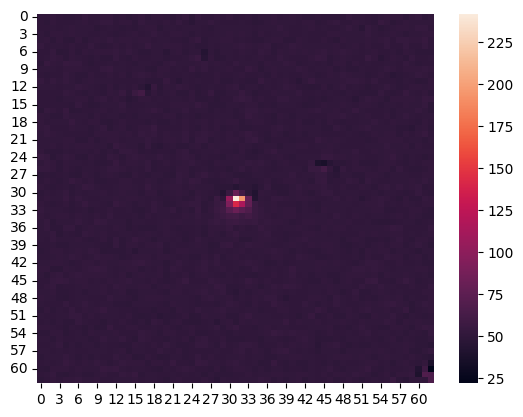

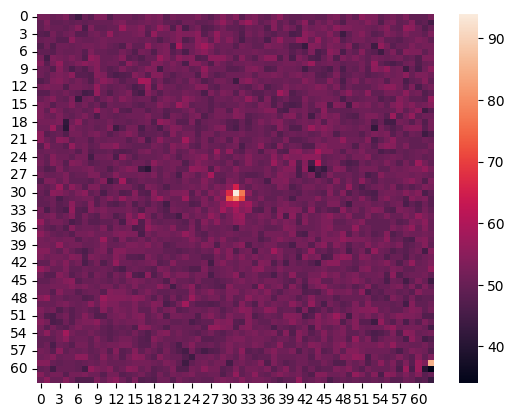

IndexError: index 199 is out of bounds for axis 0 with size 199

In [43]:
stamp_collection = normalize_to_255(stamp_collection)
print(stamp_collection.shape)

sns.heatmap(stamp_collection[0,:,:])
plt.show()
sns.heatmap(stamp_collection[1,:,:])
plt.show()

sns.heatmap(stamp_collection[199,:,:])
plt.show()


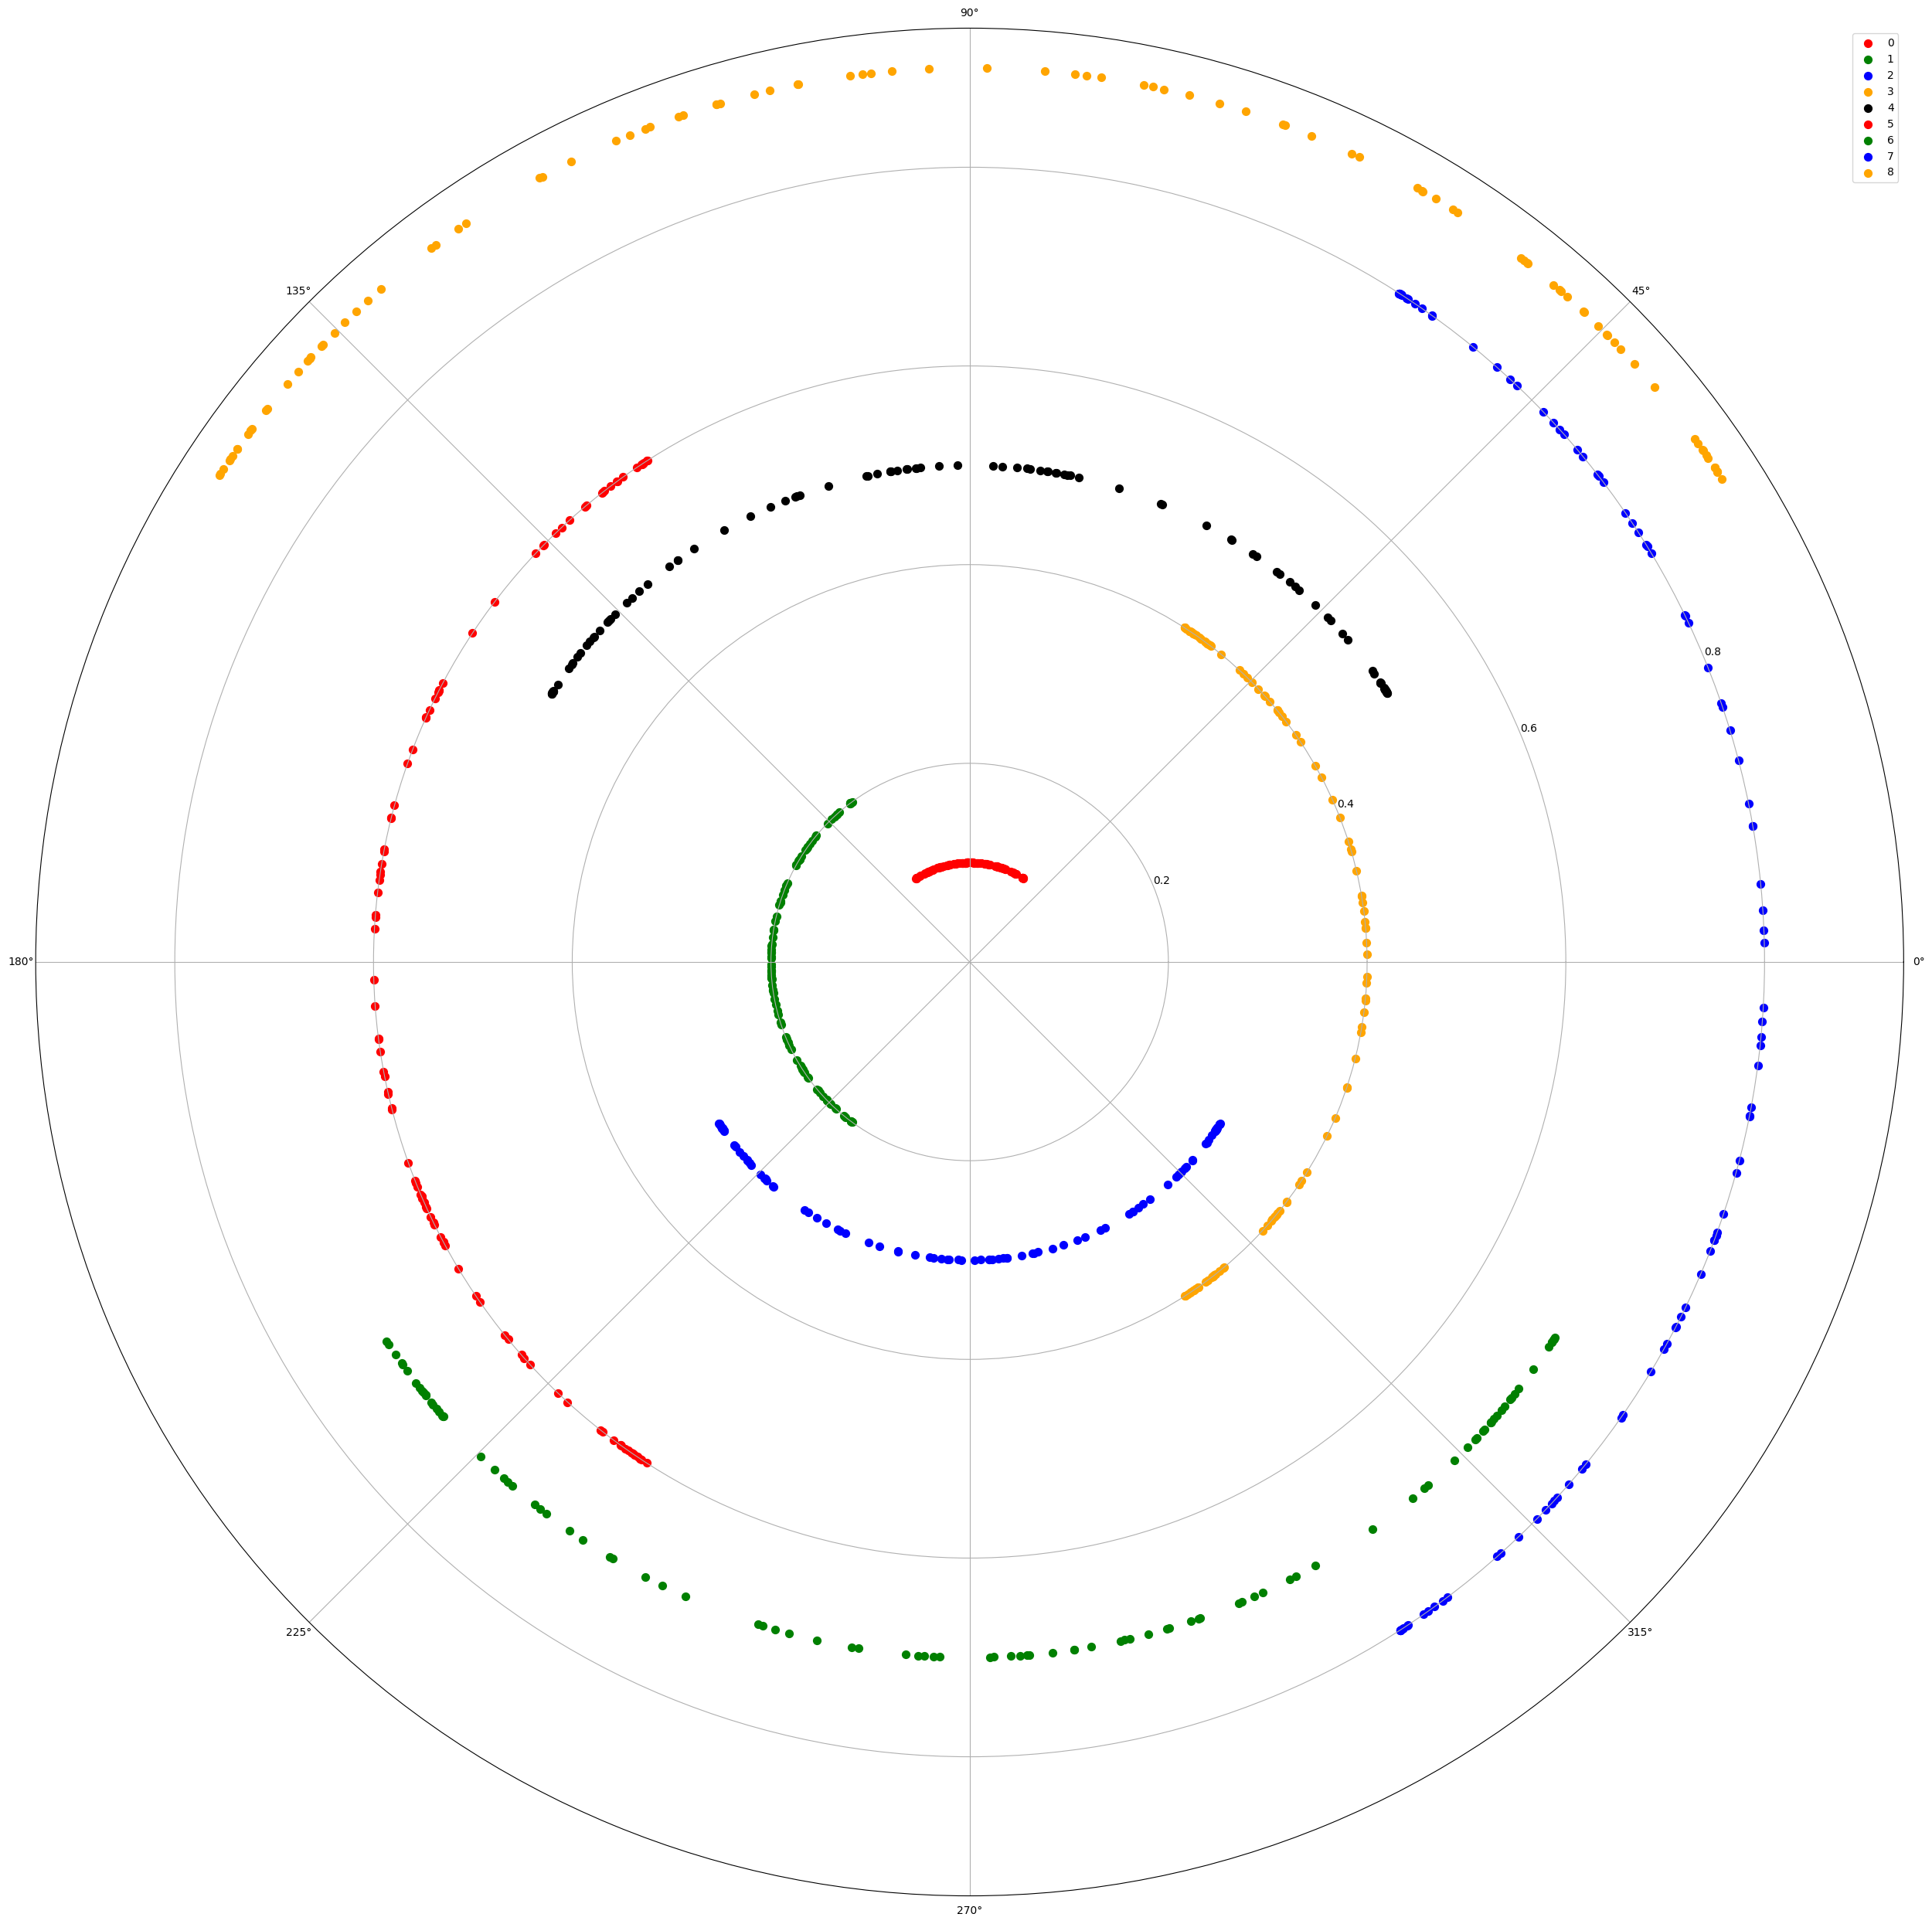

<Axes: ylabel='Count'>

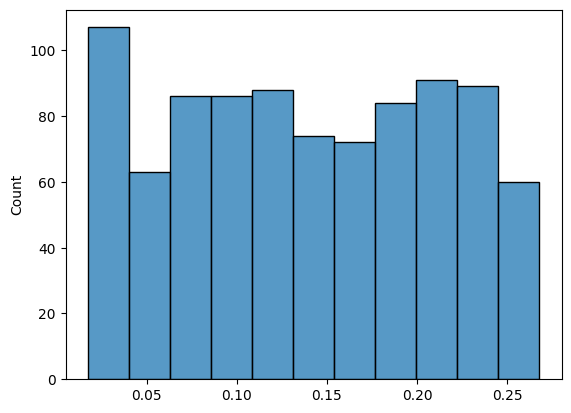

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_polar_points(theta, r, labels=None, title="Polar Plot", marker_style='o', 
                      marker_size=8, marker_color='blue', connect_points=False, 
                      grid_style='--', grid_color='gray', grid_alpha=0.3):
    """
    Create a polar plot of the given points.
    
    Parameters:
    -----------
    theta : array-like
        Angular coordinates in radians
    r : array-like
        Radial coordinates
    labels : array-like, optional
        Labels for each point
    title : str, optional
        Title of the plot
    marker_style : str, optional
        Style of the markers
    marker_size : int, optional
        Size of the markers
    marker_color : str, optional
        Color of the markers
    connect_points : bool, optional
        Whether to connect the points with lines
    grid_style : str, optional
        Style of the grid lines
    grid_color : str, optional
        Color of the grid lines
    grid_alpha : float, optional
        Transparency of the grid lines
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    # Create figure and polar axis
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection='polar')
    
    # Plot the points
    ax.scatter(theta, r, s=marker_size, c=marker_color, marker=marker_style)
    
    # Connect points with lines if requested
    if connect_points:
        # If points should be connected in a closed loop, append first point to the end
        if len(theta) > 1 and len(r) > 1:
            if theta[0] == theta[-1] and r[0] == r[-1]:
                ax.plot(theta, r, color=marker_color, alpha=0.7)
            else:
                # For open curve
                ax.plot(theta, r, color=marker_color, alpha=0.7)
    
    # Add labels if provided
    if labels is not None:
        for i, (t, rad, label) in enumerate(zip(theta, r, labels)):
            ax.annotate(label, (t, rad), fontsize=10, 
                        xytext=(5, 5), textcoords='offset points')
    
    # Customize the plot
    ax.set_title(title, fontsize=16, pad=20)
    ax.grid(True, linestyle=grid_style, color=grid_color, alpha=grid_alpha)
    
    # Customize the theta ticks (in degrees for better readability)
    ax.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
    ax.set_xticklabels(['0°', '45°', '90°', '135°', '180°', '225°', '270°', '315°'])
    
    plt.tight_layout()
    return fig, ax

theta = np.array([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4, 3*np.pi/2, 7*np.pi/4])
r = np.array([1, 2, 3, 4, 3, 2, 1, 2])
labels = [f"P{i+1}" for i in range(len(theta))]

# Example 2: A spiral
n = 100
t = np.random.uniform(-100,100,n)
t.sort()
r = np.linspace(1, 1, n)

fig = plt.figure(figsize=(25, 25))
ax = fig.add_subplot(111, projection='polar')
#print(t)
save_sin = []
# Plot the points
for h, color in zip(list(range(1,10)),10*['red','green','blue','orange','black']):
    sin = np.sin((2*np.pi*h) * t/1000)  +  h* np.pi/2#+(np.pi/(2 *h))
    save_sin.append(sin)
   
    ax.scatter(sin, r*h/sum(range(1,5)), s=50, c=color, marker='o',alpha = 1)
    
     
    
    # Customize the plot
ax.set_title('', fontsize=16, pad=20)


# Customize the theta ticks (in degrees for better readability)
ax.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax.set_xticklabels(['0°', '45°', '90°', '135°', '180°', '225°', '270°', '315°'])

plt.tight_layout()
    
plt.legend([str(i) for i in range(10)])
plt.show()


import seaborn as sns
save_sin = np.concatenate(save_sin)/(2*np.pi*h)
sns.histplot(save_sin,)

#entonces puedo representar el tiempo como una serie armonica pero de manera más compersa 


entonces puedo codificar una serie t y sus n harmonicos como sen(t), cos(t) y donde r corresponderá a el harmonico normalizado por el total de harmonicos. Así en vez de codificar en 3 dimensiones, se puede lograr 

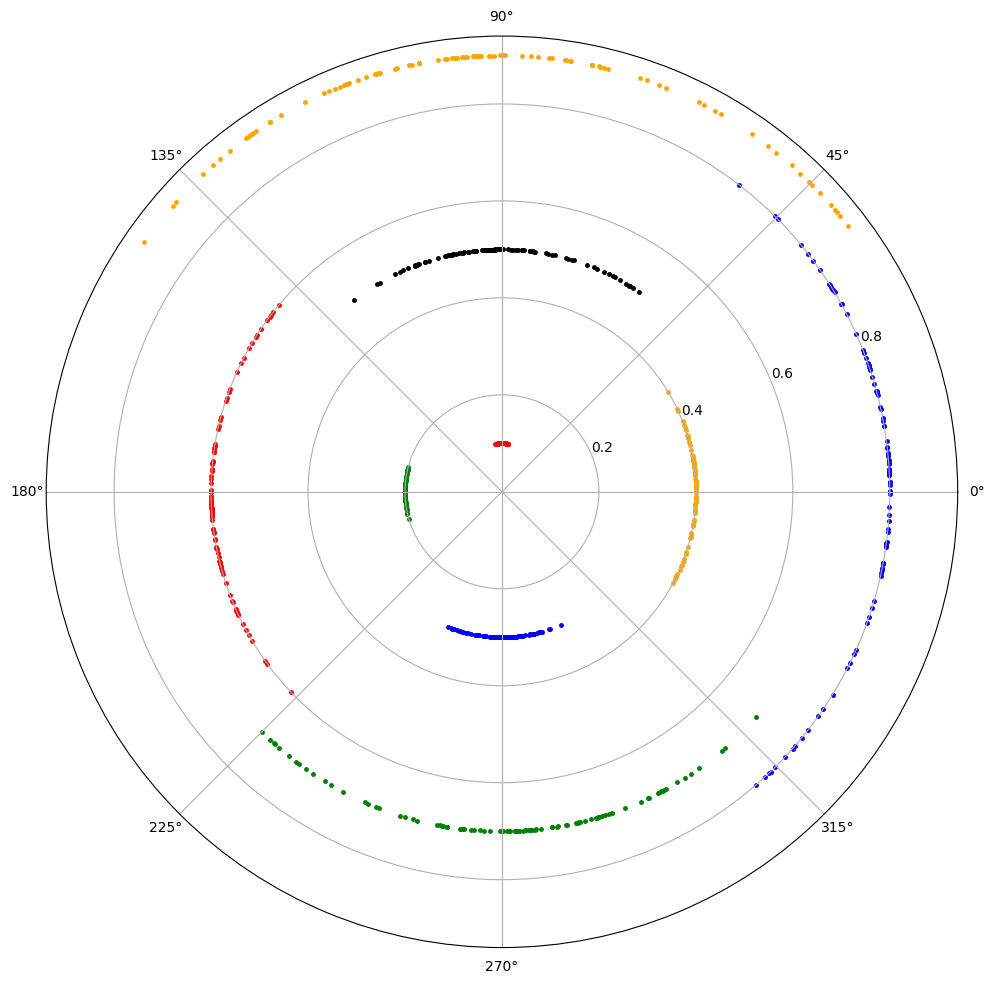

In [4]:
n = 100
t = np.random.normal(0,10,size = (n))
t.sort()

#t = np.random.uniform(-100,100,n)

r = np.linspace(1, 1, n)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='polar')
#print(t)
save_sin = []
# Plot the points
for h, color in zip(list(range(1,10)),10*['red','green','blue','orange','black']):
    sin = np.sin((2*np.pi*h) * t/1000)  +  h* np.pi/2#+(np.pi/(2 *h))
    save_sin.append(sin)
   
    ax.scatter(sin, r*h/sum(range(1,5)), s=25, c=color, marker='.',alpha = 1)
    
    # Customize the plot
ax.set_title('', fontsize=16, pad=20)
# Customize the theta ticks (in degrees for better readability)
ax.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax.set_xticklabels(['0°', '45°', '90°', '135°', '180°', '225°', '270°', '315°'])

plt.tight_layout()
    
#plt.legend([str(i) for i in range(10)])
plt.show()


import seaborn as sns
#save_sin = np.array(save_sin)/(2*np.pi*h)
#sns.histplot(save_sin,)


In [7]:
import torch
import numpy as np
n = 100
def encode_dendro(t,n_harmonics):
    print(t.shape)
    empty_sin_array = torch.empty_like(t).unsqueeze(-1).repeat(1,n_harmonics)
    empty_cos_array = torch.empty_like(t).unsqueeze(-1).repeat(1,n_harmonics)
    
    r = torch.arange(1,n_harmonics+1).repeat(n_harmonics)
    #print(r.shape)
    for h in range(1,n_harmonics + 1):
        
        #empty_angle_array[:,h-1]
        empty_sin_array[:,h-1] = np.sin((2*np.pi*h) * t/1000)  +  h* np.pi/2#+(np.pi/(2 *h))   
        empty_cos_array[:,h-1] = np.cos((2*np.pi*h) * t/1000) 
        mask = empty_cos_array[:,h-1] == 1
        empty_cos_array[:,h-1]=(empty_cos_array[:,h-1] + h*np.pi/2) * ~mask
        #r[] = r*h
    #stacked = torch.concat([empty_sin_array,empty_cos_array])
    #print(stacked.shape)
    #stacked
    r = r * (t!=0)# *h/sin_array.size(1)
    return empty_sin_array,empty_cos_array, r#torch.stack([empty_angle_array,empty_r_array]).permute(1,2,0)

t = np.random.normal(0,10,size = (n,1))
t[:10] = 0
#print(t[:10])
#sin_emb,cos_emb,r = encode_dendro(torch.tensor(t),10)

def plot_dendro(sin_array,cos_array):

    fig = plt.figure(figsize=(10, 10))
    ax1 = fig.add_subplot(121, projection='polar')
    ax2 = fig.add_subplot(122, projection='polar')
    
    
    for h, color in zip(range(sin_array.size(1)),sin_array.size(1)*['blue']):
        
        ax1.scatter(sin_array[:,h], r[:r.size(-1)//2], s=25, c='red', marker='.',alpha = 1)
        ax2.scatter(cos_array[:,h], r[:r.size(-1)//2], s=25, c='blue', marker='.',alpha = 1)
        
        # Customize the plot
    ax1.set_title('', fontsize=16, pad=20)
    # Customize the theta ticks (in degrees for better readability)
    ax1.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
    ax1.set_xticklabels(['0°', '45°', '90°', '135°', '180°', '225°', '270°', '315°'])
    plt.tight_layout()
    #plt.legend([str(i) for i in range(10)])
    plt.show()
#plot_dendro(sin_emb,cos_emb)
#print(sin_emb.shape, r.shape)


In [8]:
class Dendro(nn.Module):
    def __init__(self, n_harmonics=4, embedding_size=64, Tmax=1000.0, input_size=1):
        super(Dendro, self).__init__()
        self.alpha_sin = nn.Parameter(torch.randn(n_harmonics, embedding_size))
        self.alpha_cos = nn.Parameter(torch.randn(n_harmonics, embedding_size))
        self.beta_sin = nn.Parameter(torch.randn(n_harmonics, embedding_size))
        self.beta_cos = nn.Parameter(torch.randn(n_harmonics, embedding_size))
        self.linear_r = nn.Linear(in_features=n_harmonics, out_features=embedding_size, bias=False)

        self.Tmax = Tmax
        self.n_harmonics = n_harmonics
        self.register_buffer("ar", torch.arange(1,n_harmonics+1).unsqueeze(0).unsqueeze(0))
        self.embedding_size = embedding_size
        self.linear_proj = nn.Sequential(
            nn.Linear(in_features=input_size, out_features=embedding_size, bias=False),
            nn.GELU(),
            nn.Linear(embedding_size,embedding_size,bias = False)
        )
        
        self.dropout = nn.Dropout(0)


    def encode_dendro(self,t):
        """
        Encodes time values into sinusoidal and cosine components with harmonics.
        
        Args:
            t (torch.Tensor): Input tensor of time values with shape [batch_size, seq_len, 1]
            n_harmonics (int): Number of harmonics to compute
            
        Returns:
            tuple: (sin_array, cos_array, r) - Encoded sinusoidal, cosine components and radii
        """
        # Extract batch_size and seq_len, and squeeze the last dimension
        batch_size, seq_len, _ = t.shape
        t = t.squeeze(-1)  # [B, T, 1] -> [B, T]
        
        # Initialize arrays for sine and cosine components [B, T, H]
        sin_array = torch.zeros((batch_size, seq_len, self.n_harmonics), device=t.device)
        cos_array = torch.zeros((batch_size, seq_len, self.n_harmonics), device=t.device)

        # Create harmonic indices [H]
        harmonics = torch.arange(1, self.n_harmonics + 1, device=t.device).float()
        
        # Compute sine and cosine for each harmonic
        for h in range(1, self.n_harmonics + 1):
            # Calculate sine and cosine for current harmonic
            sin_array[:, :, h-1] = torch.sin((2 * torch.pi * h/ self.Tmax) * t) + h * torch.pi / 2
            cos_array[:, :, h-1] = torch.cos((2 * torch.pi * h/ self.Tmax) * t) # + h * torch.pi / 2
            # Apply mask for cos_array
            mask = cos_array[:, :, h-1] == 1
            cos_array[:, :, h-1] = torch.where(mask, cos_array[:, :, h-1], cos_array[:, :, h-1] + h * torch.pi / 2)
        r = torch.ones(cos_array.shape,device = cos_array.device)*(t.unsqueeze(-1) != 0) * harmonics/self.n_harmonics # Zero out r where t is zero
        r = 1-r # Create and adjust r based on t values
        return sin_array, cos_array, r

    def forward(self, x, t,mask):
        sin_emb, cos_emb,r = self.encode_dendro(t)
        
        alpha = torch.matmul(sin_emb, self.alpha_sin) + torch.matmul(
            cos_emb, self.alpha_cos
        )
        alpha = nn.functional.gelu(alpha)
        beta = torch.matmul(sin_emb , self.beta_sin) + torch.matmul(
            cos_emb, self.beta_cos 
        )
        beta = nn.functional.gelu(beta)
        return nn.functional.gelu(self.linear_proj(x)* alpha + beta)   + self.linear_r(r)
    
  

In [9]:


def plot_dendro(stack,r,ax,color = 'red'):
    for h in list(range(stack.shape[-1])):
        ax.scatter(stack[0,:,h], r[0,:,h], s=15, c=color, marker='.',alpha = 1)
    ax.set_title('', fontsize=16, pad=20)
    # Customize the theta ticks (in degrees for better readability)
    ax.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
    ax.set_xticklabels(['0°', '45°', '90°', '135°', '180°', '225°', '270°', '315°'])
    #plt.legend([str(i) for i in range(10)])


In [ ]:

class TimeFilmModified(nn.Module):
    def __init__(self, n_harmonics=4, embedding_size=64, Tmax=1000.0, input_size=1):
        super(TimeFilmModified, self).__init__()
        self.alpha_sin = nn.Parameter(torch.randn(n_harmonics, embedding_size))
        self.alpha_cos = nn.Parameter(torch.randn(n_harmonics, embedding_size))
        self.beta_sin = nn.Parameter(torch.randn(n_harmonics, embedding_size))
        self.beta_cos = nn.Parameter(torch.randn(n_harmonics, embedding_size))
        #self.linear_r = nn.Linear(in_features=n_harmonics, out_features=embedding_size, bias=False)
        self.DROPOUT = 1e-5
        self.n_harmonics = n_harmonics
        self.register_buffer("ar", torch.arange(1,n_harmonics+1).unsqueeze(0).unsqueeze(0))
        #self.embedding_size = embedding_size
        self.linear_proj = nn.Sequential(
            nn.Linear(in_features = input_size,out_features = embedding_size,bias = False)
        )
        self.const = 2 * torch.pi / Tmax
        self.dropout = nn.Dropout(self.DROPOUT)
        self.unknown_b = nn.Parameter(torch.randn(200))
        self.k = nn.Parameter(torch.tensor([1]))
    
    def energy(self,x,t):
        return 0.5*self.k*x
    
    def get_sin(self, t,mask):
        return torch.sin(self.const* self.ar*t) 

    def get_cos(self, t,mask):
        # t: Batch size x time x dim, dim = 1:
        return torch.cos(self.const * self.ar* t).masked_fill_(t == 0,0) 

    def get_sin_cos(self, t,mask):
        return self.get_sin(t,mask), self.get_cos(t,mask)
 
    def forward(self, x, t,mask):
        t = t.repeat(1,1,self.n_harmonics)
        sin_emb, cos_emb = self.get_sin_cos(t,mask)
        
        alpha = torch.matmul(sin_emb, self.alpha_sin) + torch.matmul(
            cos_emb, self.alpha_cos
        )
        
        beta = torch.matmul(sin_emb, self.beta_sin) + torch.matmul(cos_emb, self.beta_cos
        )
        
        alpha = self.dropout(alpha) 
        beta = self.dropout(beta) 
        alpha = nn.functional.gelu(alpha)
        beta = nn.functional.gelu(beta)
        
        return self.energy(self.linear_proj(x)) * alpha + beta


In [37]:

n = 100
seqlen = 200
#torch.manual_seed(1222)
x = torch.randint(-1000,1000,size = (n,seqlen,1),).float()
#x = x.masked_fill_(x ==0, 10)
t = torch.normal(0,1000,size = (n,seqlen,1),).float()
t.sort()
mask = np.random.randn(1,n,1).astype(bool)
t[:,:10]  = 0
x[:,:10]  = 0
num_harmonics = 16

sph = Sphere(n_harmonics= num_harmonics)
stack = sph(x,t,mask)
print(stack.shape)
   
#xsin,xcos,tsin,tcos = (x.detach().cpu().numpy()[:,:,:] for x in (torch.split(stack,num_harmonics,dim = -1)))
#r1,r2,r3,r4 = (x.detach().cpu().numpy()[:,:,:] for x in (torch.split(r,num_harmonics,dim = -1)))

#print(stack.shape)

torch.Size([100, 200, 16])
torch.Size([100, 200, 16])
torch.Size([100, 200, 48])
torch.Size([100, 200, 128])


In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import seaborn as sns
nbins = 50
H_cum = 0

def plot_bincount_polar(theta_array,r_array,ax):
    H_cum = 0
    for i in range(n):
        H,xe,ye = np.histogram2d(theta_array[i,:,:].flatten(),r_array[i,:,:].flatten(),bins = nbins,density=True)   
        H_cum+=H
    
    H_cum = H_cum/ H_cum.max(keepdims=True)
    # Create the pcolormesh
    #plt.imshow(H_cum)
    #
    # plt.show()
    # Set some labels

    # Create meshgrid for both coordinates

    r = np.linspace(0, nbins)  # radial values
    theta = np.linspace(0, 2*np.pi, nbins)  # angular values

    r_grid, theta_grid = np.meshgrid(r, theta)
    # Create some sample data for the color mesh
    z = H_cum

    # Create a polar projection
    

    # Create the pcolormesh
    mesh = ax.pcolormesh(theta_grid, r_grid, z, cmap='binary', shading='auto')
    ax.set_title('Polar pcolormesh example')
    ax.set_theta_zero_location('N')  # Set 0 degrees to North
    ax.set_theta_direction(-1)       # Set clockwise direction
    ax.set_title('')
    
fig = plt.figure(figsize = (20,5))
for i,array in enumerate([xsin,xcos,tsin,tcos]):
    ax = fig.add_subplot(141 + i, projection = 'polar') 
    plot_bincount_polar(array,r1,ax = ax)
 

NameError: name 'xsin' is not defined

<Figure size 2000x500 with 0 Axes>

(10, 200, 16)


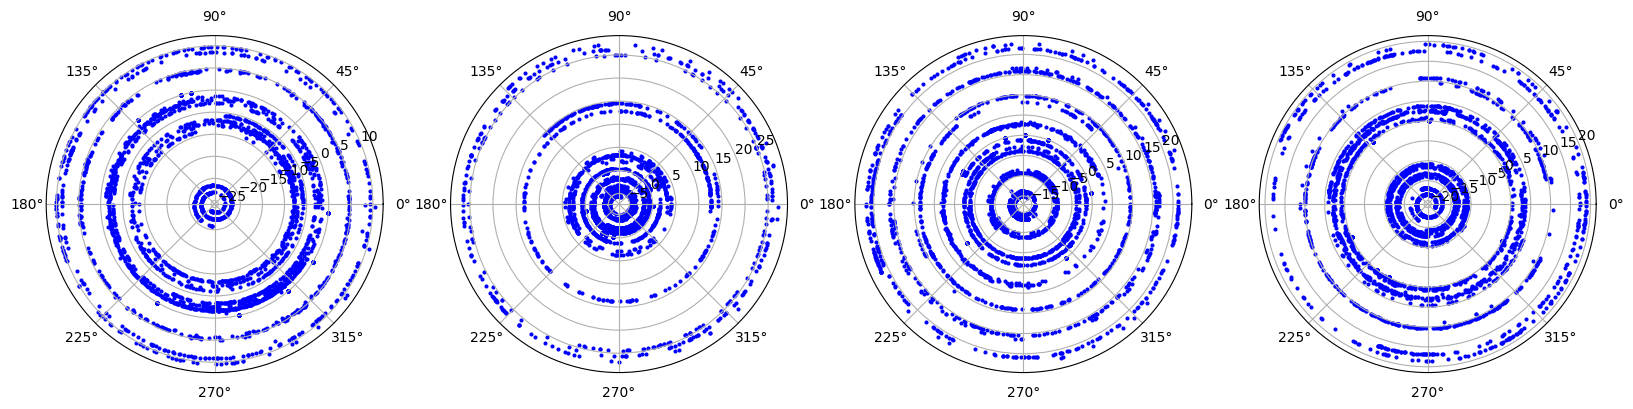

In [239]:

n = 10
seqlen = 200
#torch.manual_seed(1222)
x = torch.randint(-1000,1000,size = (n,seqlen,1),).float()
#x = x.masked_fill_(x ==0, 10)
t = torch.normal(0,1000,size = (n,seqlen,1),).float()
t.sort()
mask = np.random.randn(1,n,1).astype(bool)
t[:,:10]  = 0
x[:,:10]  = 0


dendro = Dendro()
stack,r = dendro(x,t,mask)

   
xsin,xcos,tsin,tcos = (x.detach().cpu().numpy()[:,:,:] for x in (torch.split(stack,16,dim = -1)))
r1,r2,r3,r4 = (x.detach().cpu().numpy()[:,:,:] for x in (torch.split(r,16,dim = -1)))
print(xsin.shape)
fig = plt.figure(figsize = (20,5))
for i,array in enumerate([xsin,xcos,tsin,tcos]):
    ax = fig.add_subplot(141 + i, projection = 'polar') 
    plot_dendro(array,r1*array,ax = ax, color = 'blue')

 

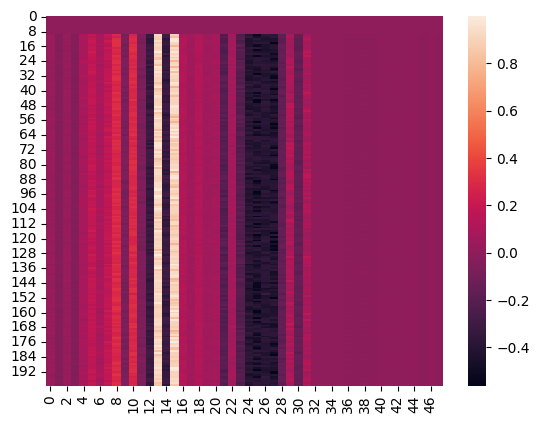

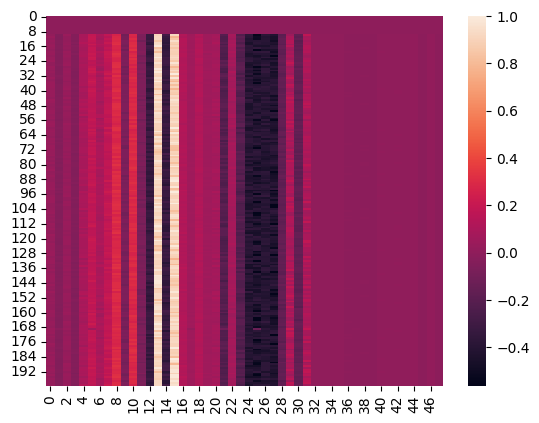

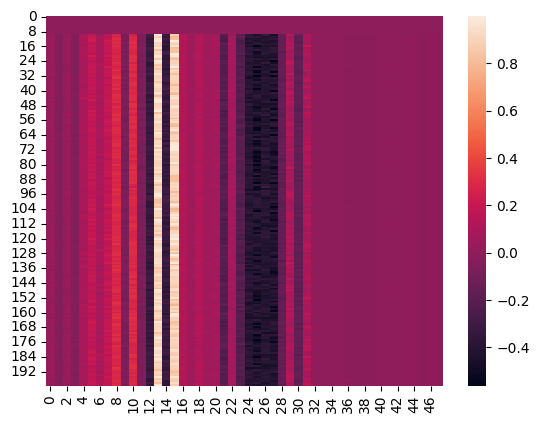

In [240]:
x = (r1 * xsin*tcos)
y = (r1*xsin*tsin)
z = (r1*tcos)

concatxyz = np.concatenate([x,y,z],axis = -1)
concatxyz = concatxyz / concatxyz.max()
import seaborn as sns

sns.heatmap(concatxyz[0,:,:])
plt.show()
sns.heatmap(concatxyz[1,:,:])
plt.show()
sns.heatmap(concatxyz[2,:,:])
plt.show()

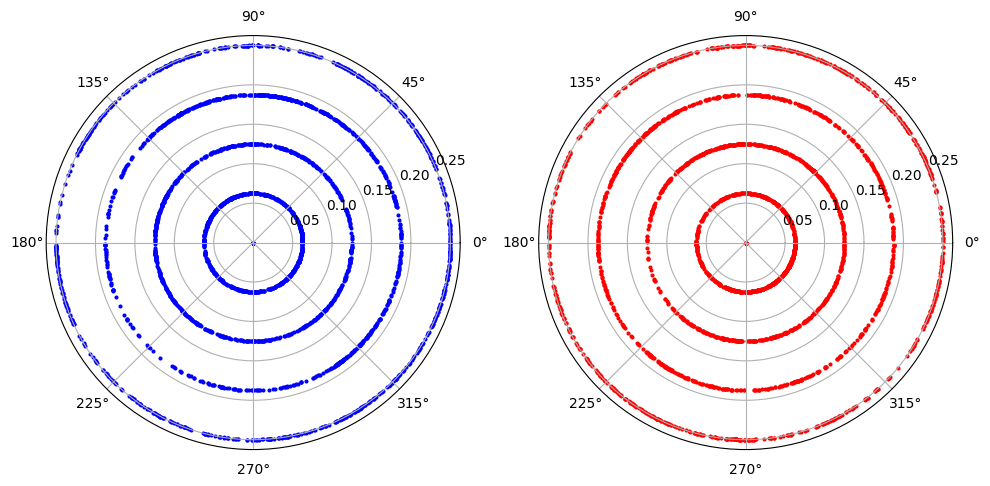

In [223]:
fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(121, projection='polar')
ax2 = fig.add_subplot(122, projection='polar')
plot_dendro(tsin,r,ax = ax1, color = 'blue')
plot_dendro(tcos,r,ax = ax2)
plt.tight_layout()
plt.show()

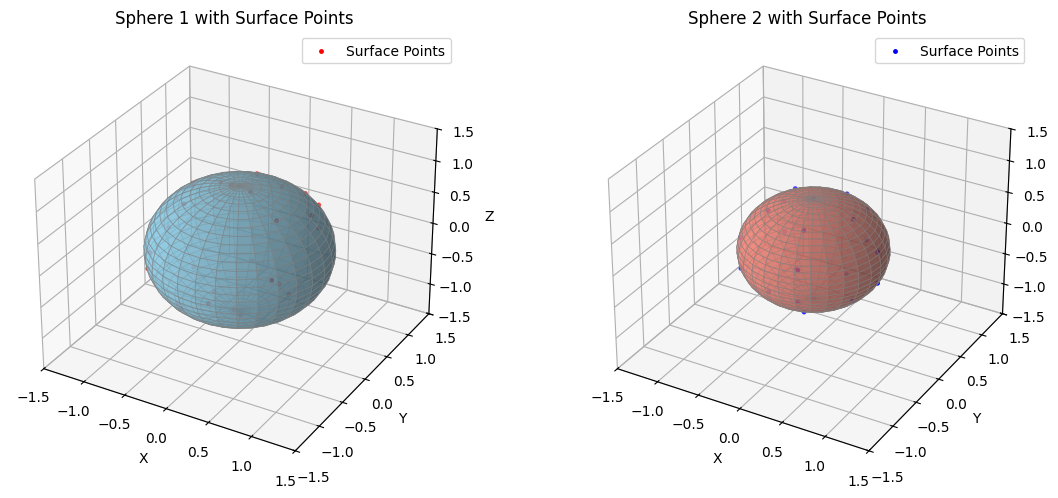

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create figure with two subplots
fig = plt.figure(figsize=(12, 5))

# Create the first sphere
ax1 = fig.add_subplot(121, projection='3d')

# Parameters for the first sphere
center1 = np.array([0, 0, 0])
radius1 = 1.0
color1 = 'skyblue'

# Create arrays for the first sphere
u1 = np.linspace(0, 2 * np.pi, 30)
v1 = np.linspace(0, np.pi, 30)
x1 = center1[0] + radius1 * np.outer(np.cos(u1), np.sin(v1))
y1 = center1[1] + radius1 * np.outer(np.sin(u1), np.sin(v1))
z1 = center1[2] + radius1 * np.outer(np.ones(np.size(u1)), np.cos(v1))

# Plot the first sphere
ax1.plot_surface(x1, y1, z1, color=color1, alpha=0.6, edgecolor='gray', linewidth=0.5)

# Generate random points on the first sphere surface
num_points1 = 30
theta1 = np.random.uniform(0, 2 * np.pi, num_points1)
phi1 = np.random.uniform(0, np.pi, num_points1)
x_points1 = center1[0] + radius1 * np.sin(phi1) * np.cos(theta1)
y_points1 = center1[1] + radius1 * np.sin(phi1) * np.sin(theta1)
z_points1 = center1[2] + radius1 * np.cos(phi1)

# Plot points on the first sphere
ax1.scatter(x_points1, y_points1, z_points1, color='red', s=25,marker = '.', label='Surface Points')

ax1.set_title('Sphere 1 with Surface Points')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_xlim([-1.5, 1.5])
ax1.set_ylim([-1.5, 1.5])
ax1.set_zlim([-1.5, 1.5])
ax1.legend()

# Create the second sphere
ax2 = fig.add_subplot(122, projection='3d')

# Parameters for the second sphere
center2 = np.array([0, 0, 0])
radius2 = 0.8
color2 = 'salmon'

# Create arrays for the second sphere
u2 = np.linspace(0, 2 * np.pi, 30)
v2 = np.linspace(0, np.pi, 30)
x2 = center2[0] + radius2 * np.outer(np.cos(u2), np.sin(v2))
y2 = center2[1] + radius2 * np.outer(np.sin(u2), np.sin(v2))
z2 = center2[2] + radius2 * np.outer(np.ones(np.size(u2)), np.cos(v2))

# Plot the second sphere
ax2.plot_surface(x2, y2, z2, color=color2, alpha=0.6, edgecolor='gray', linewidth=0.5)

# Generate points on the second sphere in a more patterned way
num_points_u = 6
num_points_v = 6
u_points = np.linspace(0, 2 * np.pi, num_points_u)
v_points = np.linspace(0, np.pi, num_points_v)
points_u, points_v = np.meshgrid(u_points, v_points)
points_u = points_u.flatten()
points_v = points_v.flatten()

x_points2 = center2[0] + radius2 * np.sin(points_v) * np.cos(points_u)
y_points2 = center2[1] + radius2 * np.sin(points_v) * np.sin(points_u)
z_points2 = center2[2] + radius2 * np.cos(points_v)

# Plot points on the second sphere
ax2.scatter(x_points2, y_points2, z_points2, color='blue',marker = '.', s=25, label='Surface Points')

ax2.set_title('Sphere 2 with Surface Points')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_xlim([-1.5, 1.5])
ax2.set_ylim([-1.5, 1.5])
ax2.set_zlim([-1.5, 1.5])
ax2.legend()

# Adjust layout and display
plt.tight_layout()
plt.show()

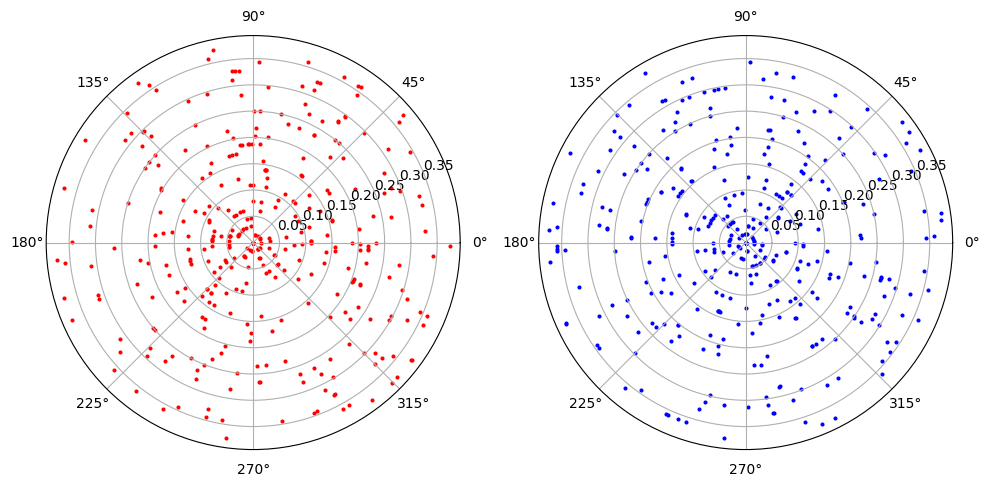

In [33]:


def plot_dendro(sin_array,cos_array):

    fig = plt.figure(figsize=(10, 10))
    ax1 = fig.add_subplot(121, projection='polar')
    ax2 = fig.add_subplot(122, projection='polar')
    for h, color in zip(list(range(sin_array.shape[-1])),(sin_array.shape[1]-1)*['blue']):
        
        ax1.scatter(sin_array[0,:,h], r[0,:,h], s=15, c='red', marker='.',alpha = 1)
        ax2.scatter(cos_array[0,:,h], r[0,:,h], s=15, c='blue', marker='.',alpha = 1)
        
        # Customize the plot
    ax1.set_title('', fontsize=16, pad=20)
    # Customize the theta ticks (in degrees for better readability)
    ax1.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
    ax1.set_xticklabels(['0°', '45°', '90°', '135°', '180°', '225°', '270°', '315°'])
    plt.tight_layout()
    #plt.legend([str(i) for i in range(10)])
    plt.show()

plot_dendro(sin_emb,cos_emb)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def plot_polar_points(t, r, title="Polar Plot", marker_style='.', 
                      marker_size=8, marker_color='red', connect_points=False):
    """
    Create a polar plot of the given points.
    
    Parameters:
    -----------
    theta : array-like
        Angular coordinates in radians
    r : array-like
        Radial coordinates
    title : str, optional
        Title of the plot
    marker_style : str, optional
        Style of the markers
    marker_size : int, optional
        Size of the markers
    marker_color : str, optional
        Color of the markers
    connect_points : bool, optional
        Whether to connect the points with lines
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """

    # Create figure and polar axis
    fig = plt.figure(figsize=(12, 4))
    ax1 = fig.add_subplot(131, projection='polar')
    ax1.set_title('sin(t)')
    scatter1 = ax1.scatter([], [], s=marker_size, c='blue', marker=marker_style)
    
    
    
    ax2 = fig.add_subplot(132, projection='polar')
    ax2.set_title('cos(t)')
    
    scatter2 = ax2.scatter([], [], s=marker_size, c='red', marker=marker_style)#ax = fig.add_subplot(131, projection='polar') 
    
    ax1.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
    ax1.set_xticklabels(['0°', '45°', '90°', '135°', '180°', '225°', '270°', '315°'])
    
    # Set initial r limits
    ax1.set_ylim(0, 1.1 * np.max(r))
    
    ax2.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
    ax2.set_xticklabels(['0°', '45°', '90°', '135°', '180°', '225°', '270°', '315°'])
    
    # Set initial r limits
    ax2.set_ylim(0, 1.1 * np.max(r))
    
    
    
    
    
    ax3 = fig.add_subplot(133, projection='polar')
    ax3.set_title('tan(t)')
    
    scatter3 = ax3.scatter([], [], s=marker_size, c='green', marker=marker_style)#ax = fig.add_subplot(131, projection='polar') 
    plt.tight_layout()
    return fig, ax1,ax2,ax3, scatter1,scatter2,scatter3

# Generate data for animation
n = 50
t = np.random.uniform(0,10000, n)  # Full circle
t.sort()

r = np.ones(n)

# Create initial plot
fig, ax1,ax2, ax3,scatter1,scatter2,scatter3 = plot_polar_points(theta, r,marker_size=15,title="cos in Polar Coordinates")

def update(frame):
    """Update function for animation - draws the polar plot one point at a time"""
    # Get data up to the current frame
    current_t = t[:frame+1]
    current_r = r[:frame+1]
    
    
    # Update scatter plot data
    scatter1.set_offsets(np.column_stack([ np.cos((2*np.pi* current_t)/1000), current_r]))
    scatter2.set_offsets(np.column_stack([np.cos(2*np.pi*current_t/1000), current_r]))
    scatter3.set_offsets(np.column_stack([np.tan(2*np.pi*current_t), current_r]))
    
    # Return the artists that need to be redrawn
    return scatter1, scatter2,scatter3

# Create animation with blitting enabled
animation = FuncAnimation(fig, update, frames=n, interval=100, blit=True)

# Display the animation in the notebook
# To save the animation instead, use: animation.save('animation.gif', writer='pillow')
HTML(animation.to_jshtml())

In [ ]:

# Create a figure and axis
fig, ax = plt.subplots(figsize=(4, 4))
 
data = np.array(collect_stamps)
#print(data.shape)
 

data = data /data.max(axis = 0) >=0
print(data.shape)
# Create the initial imshow plot
im = ax.imshow(data[0], cmap='binary', animated=True)
plt.colorbar(im, ax=ax, label='Value')
ax.set_title('Animated imshow')
ax.axis('off')
# Function to update the plot for each animation frame
def update(frame):
    """Update function for animation - generates new data for each frame"""
    # For this example, we'll generate new random data for each frame
    # In a real application, you would update this with your actual data
    new_data = data[frame]
    
    # Update the imshow data
    im.set_array(new_data)
    
    # Update title to show frame number
    ax.set_title(f'Animated imshow - Frame {frame}')
    
    return [im]

# Create animation
# frames: number of frames to generate
# interval: delay between frames in milliseconds
animation = FuncAnimation(fig, update, frames=data.shape[0], interval=100, blit=False)

# Display the animation in the notebook
# To save the animation instead, use: animation.save('animation.gif', writer='pillow')
HTML(animation.to_jshtml())

In [ ]:
data[:,:,0].shape
import seaborn as sns

sns.heatmap(data[:,:,0].T, cmap = 'binary')
plt.xlabel('muestras')
plt.ylabel('columnas de pixeles')
plt.show()
sns.heatmap(data[:,0,:].T, cmap = 'binary')
plt.xlabel('muestras')
plt.ylabel('filas de pixeles')

In [ ]:
sns.heatmap(data.reshape(data.shape[0],-1))

casi cuatromil senales de 90 muestras. Threshold fijo en 0.5, pero quiza el modelo podría elegir el thr.

In [ ]:
import json


string = client.get_avro('ZTF18abzsaee')
json.loads(str().replace('b\'Obj\\x01\\x04\\x16avro.schema\\x82|',''))

